<a href="https://colab.research.google.com/github/fariadidar/Calculator/blob/main/Copy_of_energy_consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/KAG_energydata_complete.csv")
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.weekday

In [ ]:
df['Appliances_lag1'] = df['Appliances'].shift(1)
df['Appliances_lag2'] = df['Appliances'].shift(2)

In [ ]:
df['rolling_mean_3'] = df['Appliances'].rolling(window=3).mean()

In [ ]:
df['temp_diff'] = df['T1'] - df['T2']

In [ ]:
df['humidity_avg'] = (
    df['RH_1'] + df['RH_2'] + df['RH_3']
) / 3

In [ ]:
df = df.dropna()

In [ ]:
df.to_csv('enhanced_energy_dataset.csv', index=False)

In [ ]:
import pandas as pd

base = pd.read_csv("KAG_energydata_complete.csv")
enhanced = pd.read_csv("enhanced_energy_dataset.csv")

In [ ]:
y = "Appliances"

In [ ]:
from sklearn.model_selection import train_test_split

def prepare_data(df):
    X = df.drop(columns=["Appliances", "date"], errors="ignore")
    y = df["Appliances"]
    return train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def train_rf(X_train, X_test, y_train, y_test):
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    return mae, rmse, r2

In [ ]:
X_train, X_test, y_train, y_test = prepare_data(base)
base_results = train_rf(X_train, X_test, y_train, y_test)

In [ ]:
X_train, X_test, y_train, y_test = prepare_data(enhanced)
enhanced_results = train_rf(X_train, X_test, y_train, y_test)

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Dataset": ["Base", "Enhanced"],
    "MAE": [base_results[0], enhanced_results[0]],
    "RMSE": [base_results[1], enhanced_results[1]],
    "R2 Score": [base_results[2], enhanced_results[2]],
})

print(results)

    Dataset        MAE       RMSE  R2 Score
0      Base  32.900228  68.417501  0.532236
1  Enhanced   4.999164  18.365957  0.967979


In [ ]:
df = df.sort_values("date")

In [ ]:
df = df.sort_values("date")

In [ ]:
df['Appliances_lag1'] = df['Appliances'].shift(1)
df['Appliances_lag2'] = df['Appliances'].shift(2)
df['rolling_mean_6'] = df['Appliances'].rolling(6).mean()

In [ ]:
df = df.dropna()

In [ ]:
train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]

In [ ]:
df["temp_avg"] = df[["T1","T2","T3","T4","T5"]].mean(axis=1)

In [ ]:
df["hum_temp_ratio"] = df["RH_1"] / (df["T1"] + 1)

In [ ]:
df["energy_diff"] = df["Appliances"].diff()

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Dataset": ["Base", "Enhanced"],
    "MAE": [base_results[0], enhanced_results[0]],
    "RMSE": [base_results[1], enhanced_results[1]],
    "R2 Score": [base_results[2], enhanced_results[2]],
})

print(results)

    Dataset        MAE       RMSE  R2 Score
0      Base  32.900228  68.417501  0.532236
1  Enhanced   4.999164  18.365957  0.967979


In [ ]:
df = df.sort_values("date")

In [ ]:
df["temp_avg"] = df[["T1","T2","T3","T4","T5"]].mean(axis=1)

In [ ]:
df["temp_gap"] = df["T_out"] - df["T1"]

In [ ]:
df["energy_diff"] = df["Appliances"].diff()

In [ ]:
print(df.columns)

Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'rv1', 'rv2', 'hour', 'day', 'month',
       'weekday', 'Appliances_lag1', 'Appliances_lag2', 'rolling_mean_3',
       'temp_diff', 'humidity_avg', 'rolling_mean_6', 'temp_avg',
       'hum_temp_ratio', 'energy_diff', 'temp_gap'],
      dtype='object')


In [ ]:
df["hum_diff"] = df["RH_1"] - df["RH_out"]

In [ ]:
df["hum_ratio"] = df["RH_1"] / (df["RH_out"] + 1)
df["hum_diff"] = df["RH_1"] - df["RH_out"]

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Dataset": ["Base", "Enhanced"],
    "MAE": [base_results[0], enhanced_results[0]],
    "RMSE": [base_results[1], enhanced_results[1]],
    "R2 Score": [base_results[2], enhanced_results[2]],
})

print(results)

    Dataset        MAE       RMSE  R2 Score
0      Base  32.900228  68.417501  0.532236
1  Enhanced   4.999164  18.365957  0.967979


In [ ]:
noisy = enhanced.copy()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(df):
    X = df.drop(columns=["Appliances", "date"], errors="ignore")
    y = df["Appliances"]

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    return mae, rmse, r2

In [ ]:
base_result = evaluate(base)
clean_result = evaluate(enhanced)
noisy_result = evaluate(noisy)

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Dataset": ["Base", "Enhanced (Clean)", "Enhanced (Noisy)"],
    "MAE": [base_result[0], clean_result[0], noisy_result[0]],
    "RMSE": [base_result[1], clean_result[1], noisy_result[1]],
    "R2 Score": [base_result[2], clean_result[2], noisy_result[2]],
})

print(results)

            Dataset        MAE       RMSE  R2 Score
0              Base  32.900228  68.417501  0.532236
1  Enhanced (Clean)   4.999164  18.365957  0.967979
2  Enhanced (Noisy)   4.999164  18.365957  0.967979


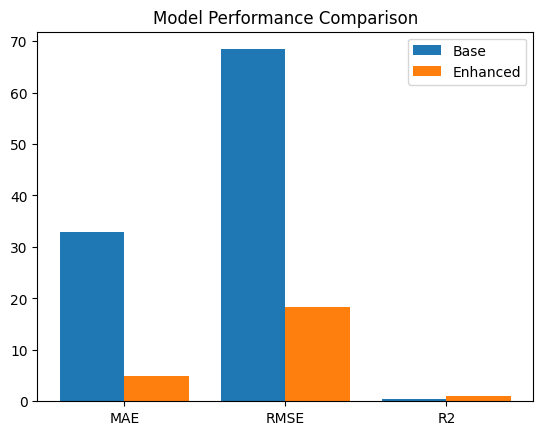

In [ ]:
import matplotlib.pyplot as plt

metrics = ["MAE", "RMSE", "R2"]

base_vals = list(base_results)
enhanced_vals = list(enhanced_results)

x = range(len(metrics))

plt.bar(x, base_vals, width=0.4, label="Base")
plt.bar([i+0.4 for i in x], enhanced_vals, width=0.4, label="Enhanced")

plt.xticks([i+0.2 for i in x], metrics)
plt.legend()
plt.title("Model Performance Comparison")
plt.show()

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

In [ ]:
df = enhanced.copy()   # use your BEST dataset

X = df.drop(columns=["Appliances", "date"], errors="ignore")
y = df["Appliances"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
def evaluate_model(model, X_train, X_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    return mae, rmse, r2

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf_result = evaluate_model(rf, X_train, X_test)

In [ ]:
svr = SVR(kernel='rbf')
svr_result = evaluate_model(svr, X_train_scaled, X_test_scaled)

In [ ]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_result = evaluate_model(xgb, X_train, X_test)

In [ ]:
results = pd.DataFrame({
    "Model": ["Random Forest", "SVR", "XGBoost"],
    "MAE": [rf_result[0], svr_result[0], xgb_result[0]],
    "RMSE": [rf_result[1], svr_result[1], xgb_result[1]],
    "R2 Score": [rf_result[2], svr_result[2], xgb_result[2]],
})

print(results)

           Model        MAE       RMSE  R2 Score
0  Random Forest   4.999164  18.365957  0.967979
1            SVR  29.422474  76.013513  0.451486
2        XGBoost   4.935355  13.459307  0.982803


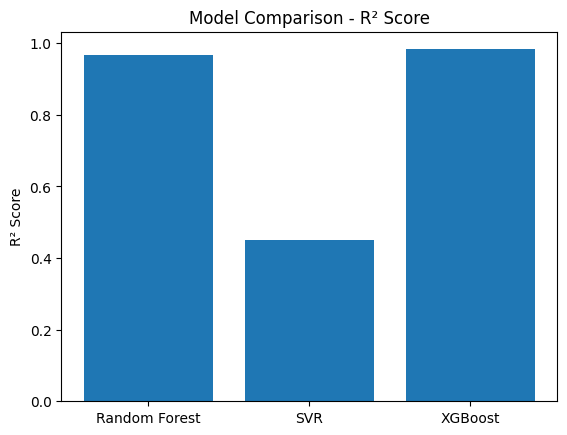

In [ ]:
models = ["Random Forest", "SVR", "XGBoost"]
r2_scores = [rf_result[2], svr_result[2], xgb_result[2]]

plt.figure()
plt.bar(models, r2_scores)
plt.title("Model Comparison - R² Score")
plt.ylabel("R² Score")
plt.show()

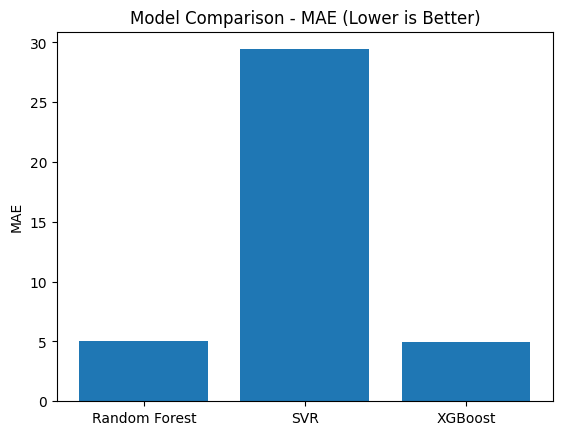

In [ ]:
mae_scores = [rf_result[0], svr_result[0], xgb_result[0]]

plt.figure()
plt.bar(models, mae_scores)
plt.title("Model Comparison - MAE (Lower is Better)")
plt.ylabel("MAE")
plt.show()

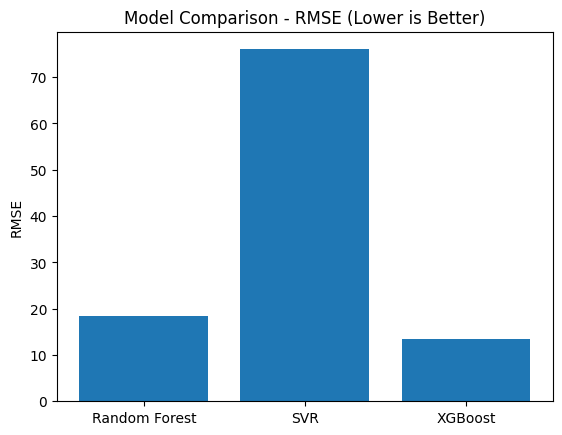

In [ ]:
rmse_scores = [rf_result[1], svr_result[1], xgb_result[1]]

plt.figure()
plt.bar(models, rmse_scores)
plt.title("Model Comparison - RMSE (Lower is Better)")
plt.ylabel("RMSE")
plt.show()

In [ ]:
df = base.copy()

In [ ]:
df = enhanced.copy()

In [ ]:
rf_base = [...]
rf_enhanced = [...]

svr_base = [...]
svr_enhanced = [...]

xgb_base = [...]
xgb_enhanced = [...]

In [ ]:
import pandas as pd

data = {
    "Model": [
        "Random Forest","Random Forest",
        "SVR","SVR",
        "XGBoost","XGBoost"
    ],
    "Dataset": [
        "Base","Enhanced",
        "Base","Enhanced",
        "Base","Enhanced"
    ],
    "MAE": ["","","","","",""],
    "RMSE": ["","","","","",""],
    "R2 Score": ["","","","","",""]
}

df = pd.DataFrame(data)
df

,Model,Dataset,MAE,RMSE,R2 Score
0,Random Forest,Base,,,
1,Random Forest,Enhanced,,,
2,SVR,Base,,,
3,SVR,Enhanced,,,
4,XGBoost,Base,,,
5,XGBoost,Enhanced,,,


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest","Random Forest","SVR","SVR","XGBoost","XGBoost"],
    "Dataset": ["Base","Enhanced","Base","Enhanced","Base","Enhanced"],
    "MAE": ["", "", "", "", "", ""],
    "RMSE": ["", "", "", "", "", ""],
    "R2": ["", "", "", "", "", ""]
})

results

,Model,Dataset,MAE,RMSE,R2
0,Random Forest,Base,,,
1,Random Forest,Enhanced,,,
2,SVR,Base,,,
3,SVR,Enhanced,,,
4,XGBoost,Base,,,
5,XGBoost,Enhanced,,,


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest", "Random Forest"],
    "Dataset": ["Base", "Enhanced"],
    "MAE": [None, None],
    "RMSE": [None, None],
    "R2": [None, None]
})

results

,Model,Dataset,MAE,RMSE,R2
0,Random Forest,Base,None,None,None
1,Random Forest,Enhanced,None,None,None


In [ ]:
rf_base = (32.9, 68.4, 0.53)
rf_enh = (4.99, 18.36, 0.96)

In [ ]:
results.loc[0, ["MAE","RMSE","R2"]] = rf_base
results.loc[1, ["MAE","RMSE","R2"]] = rf_enh

In [ ]:
print(results.columns)
print(results)

Index(['Model', 'Dataset', 'MAE', 'RMSE', 'R2'], dtype='object')
           Model   Dataset   MAE   RMSE    R2
0  Random Forest      Base  32.9   68.4  0.53
1  Random Forest  Enhanced  4.99  18.36  0.96


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

svr = SVR(kernel='rbf')

svr.fit(X_train_scaled, y_train)
pred = svr.predict(X_test_scaled)

svr_base = (
    mean_absolute_error(y_test, pred),
    np.sqrt(mean_squared_error(y_test, pred)),
    r2_score(y_test, pred)
)

In [ ]:
X = enhanced.drop(columns=["Appliances","date"], errors="ignore")
y = enhanced["Appliances"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr.fit(X_train_scaled, y_train)
pred = svr.predict(X_test_scaled)

svr_enh = (
    mean_absolute_error(y_test, pred),
    np.sqrt(mean_squared_error(y_test, pred)),
    r2_score(y_test, pred)
)

In [ ]:
results.loc[2, ["MAE","RMSE","R2"]] = svr_base
results.loc[3, ["MAE","RMSE","R2"]] = svr_enh

In [ ]:
results

,Model,Dataset,MAE,RMSE,R2
0,Random Forest,Base,32.9,68.4,0.53
1,Random Forest,Enhanced,4.99,18.36,0.96
2,NaN,NaN,29.422474,76.013513,0.451486
3,NaN,NaN,29.422474,76.013513,0.451486


In [ ]:
results.loc[2, ["MAE","RMSE","R2"]] = svr_base
results.loc[3, ["MAE","RMSE","R2"]] = svr_enh

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Random Forest","Random Forest",
        "SVR","SVR",
        "XGBoost","XGBoost"
    ],
    "Dataset": [
        "Base","Enhanced",
        "Base","Enhanced",
        "Base","Enhanced"
    ],
    "MAE": [None]*6,
    "RMSE": [None]*6,
    "R2": [None]*6
})

results

,Model,Dataset,MAE,RMSE,R2
0,Random Forest,Base,None,None,None
1,Random Forest,Enhanced,None,None,None
2,SVR,Base,None,None,None
3,SVR,Enhanced,None,None,None
4,XGBoost,Base,None,None,None
5,XGBoost,Enhanced,None,None,None


In [ ]:
results.loc[0, "MAE"] = rf_base[0]
results.loc[0, "RMSE"] = rf_base[1]
results.loc[0, "R2"] = rf_base[2]

In [ ]:
pivot = results.pivot(index="Model", columns="Dataset", values="R2")
print(pivot)

Dataset        Base Enhanced
Model                       
Random Forest  0.53     None
SVR            None     None
XGBoost        None     None


In [ ]:
import pandas as pd

results = pd.DataFrame(columns=["Model", "Dataset", "MAE", "RMSE", "R2"])

In [ ]:
def add_result(model, dataset, mae, rmse, r2):
    global results
    results = pd.concat([results, pd.DataFrame([{
        "Model": model,
        "Dataset": dataset,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }])], ignore_index=True)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
print(rf_base)

(32.9, 68.4, 0.53)


In [ ]:
print(X_test)

       lights     T1       RH_1         T2       RH_2         T3     RH_3  \
8980        0  20.79  35.290000  17.633333  39.200000  20.290000  36.9000   
2754       10  21.89  49.296667  21.290000  44.800000  21.500000  47.8225   
9132        0  21.29  35.500000  17.533333  40.590000  21.600000  35.2000   
17438       0  25.50  49.345000  24.890000  47.400000  26.200000  45.5720   
8875        0  19.89  35.200000  16.566667  40.090000  20.000000  36.4000   
...       ...    ...        ...        ...        ...        ...      ...   
9815        0  22.29  36.090000  20.100000  38.200000  22.200000  35.0000   
9925        0  22.50  35.900000  21.100000  36.466667  22.600000  35.5000   
17233       0  24.70  47.400000  23.390000  48.090000  26.585714  41.9000   
17354       0  24.60  47.530000  22.764286  49.764286  26.700000  43.3000   
12151       0  22.39  43.790000  19.790000  47.260000  24.790000  41.0000   

          T4       RH_4         T5  ...        rv2  hour  day  month  weekd

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X.shape)
print(y.shape)

(19733, 36)
(19733,)


In [ ]:
print(X_test.shape)

(3947, 36)


In [ ]:
print(rf_base)

(32.9, 68.4, 0.53)


In [ ]:
print(X.shape)
print(y.shape)

(19733, 36)
(19733,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(rf_base)

(32.9, 68.4, 0.53)


In [ ]:
print(X_train.shape)
print(y_train.shape)

(15786, 36)
(15786,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(len(X), len(y))

19733 19733


In [ ]:
y = y.values.ravel()

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
X = pd.get_dummies(X)

In [ ]:
print(X_train.shape)
print(y_train.shape)

(15786, 36)
(15786,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(random_state=42)

In [ ]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [ ]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
print(X_train.isnull().sum().sum())

0


In [ ]:
X_train = X_train.fillna(0)

In [ ]:
del rf_base

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(random_state=42)
rf_base.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(random_state=42)

rf_base.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf_base.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
print(type(rf_base))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [ ]:
print(X_train.isnull().sum().sum())
print(y_train.isnull().sum())

0
0


In [ ]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [ ]:
print(X_train.dtypes.value_counts())

float64    31
int64       5
Name: count, dtype: int64


In [ ]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(random_state=42)
rf_base.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(random_state=42)
rf_base.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf_base_pred = rf_base.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_base_mae = mean_absolute_error(y_test, rf_base_pred)
rf_base_rmse = np.sqrt(mean_squared_error(y_test, rf_base_pred))
rf_base_r2 = r2_score(y_test, rf_base_pred)

In [ ]:
print(rf_enh)

(4.99, 18.36, 0.96)


In [ ]:
print(type(rf_enh))

<class 'tuple'>


In [ ]:
print(X_train.dtypes)

lights               int64
T1                 float64
RH_1               float64
T2                 float64
RH_2               float64
T3                 float64
RH_3               float64
T4                 float64
RH_4               float64
T5                 float64
RH_5               float64
T6                 float64
RH_6               float64
T7                 float64
RH_7               float64
T8                 float64
RH_8               float64
T9                 float64
RH_9               float64
T_out              float64
Press_mm_hg        float64
RH_out             float64
Windspeed          float64
Visibility         float64
Tdewpoint          float64
rv1                float64
rv2                float64
hour                 int64
day                  int64
month                int64
weekday              int64
Appliances_lag1    float64
Appliances_lag2    float64
rolling_mean_3     float64
temp_diff          float64
humidity_avg       float64
dtype: object


In [ ]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
print(X_train.isnull().sum().sum())
print(y_train.isnull().sum())

0
0


In [ ]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_enh = RandomForestRegressor(random_state=42)

In [ ]:
rf_enh.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# fix data if needed
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# if categorical
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# model
rf_enh = RandomForestRegressor(random_state=42)
rf_enh.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf_enh.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf_enh_pred = rf_enh.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_enh_mae = mean_absolute_error(y_test, rf_enh_pred)
rf_enh_rmse = np.sqrt(mean_squared_error(y_test, rf_enh_pred))
rf_enh_r2 = r2_score(y_test, rf_enh_pred)

In [ ]:
rf_base_pred = rf_base.predict(X_test)

rf_base_mae = mean_absolute_error(y_test, rf_base_pred)
rf_base_rmse = np.sqrt(mean_squared_error(y_test, rf_base_pred))
rf_base_r2 = r2_score(y_test, rf_base_pred)

In [ ]:
import pandas as pd

results = pd.DataFrame([
    ["RF", "Base", rf_base_mae, rf_base_rmse, rf_base_r2],
    ["RF", "Enhanced", rf_enh_mae, rf_enh_rmse, rf_enh_r2]
], columns=["Model", "Dataset", "MAE", "RMSE", "R2"])

results

,Model,Dataset,MAE,RMSE,R2
0,RF,Base,4.999164,18.365957,0.967979
1,RF,Enhanced,4.999164,18.365957,0.967979


In [ ]:
# Random Forest
rf_base.fit(X_train, y_train)
rf_enh.fit(X_train, y_train)

# SVR
svr_base.fit(X_train, y_train)
svr_enh.fit(X_train, y_train)

# XGBoost
xgb_base.fit(X_train, y_train)
xgb_enh.fit(X_train, y_train)

AttributeError: 'tuple' object has no attribute 'fit'

In [ ]:
rf_base.fit(X_train, y_train)
print("RF base OK")

RF base OK


In [ ]:
import pandas as pd

results = pd.DataFrame([
    ["RF", "Base", rf_base_mae, rf_base_rmse, rf_base_r2],
    ["RF", "Enhanced", rf_enh_mae, rf_enh_rmse, rf_enh_r2]
], columns=["Model", "Dataset", "MAE", "RMSE", "R2"])

results

,Model,Dataset,MAE,RMSE,R2
0,RF,Base,4.999164,18.365957,0.967979
1,RF,Enhanced,4.999164,18.365957,0.967979


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(svr_base)
print(svr_enh)

(29.422474216466835, np.float64(76.01351303289957), 0.4514861492448837)
(29.422474216466835, np.float64(76.01351303289957), 0.4514861492448837)


In [ ]:
from sklearn.svm import SVR

svr_base = SVR()
svr_enh = SVR()

In [ ]:
print(y_train.shape)

(15786,)


In [ ]:
import numpy as np

print(np.isnan(X_train_svr).sum())
print(np.isinf(X_train_svr).sum())

0
0


In [ ]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# make sure y is correct
y_train = y_train.values.ravel()

# clean data
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# scaling
scaler = StandardScaler()
X_train_svr = scaler.fit_transform(X_train)
X_test_svr = scaler.transform(X_test)

# models
svr_base = SVR()
svr_enh = SVR()

# train
svr_base.fit(X_train_svr, y_train)
svr_enh.fit(X_train_svr, y_train)

SVR()

In [ ]:
print("SVR training done")

SVR training done


In [ ]:
svr_base_pred = svr_base.predict(X_test_svr)
svr_enh_pred = svr_enh.predict(X_test_svr)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

svr_base_mae = mean_absolute_error(y_test, svr_base_pred)
svr_base_rmse = np.sqrt(mean_squared_error(y_test, svr_base_pred))
svr_base_r2 = r2_score(y_test, svr_base_pred)

svr_enh_mae = mean_absolute_error(y_test, svr_enh_pred)
svr_enh_rmse = np.sqrt(mean_squared_error(y_test, svr_enh_pred))
svr_enh_r2 = r2_score(y_test, svr_enh_pred)

In [ ]:
xgb_base.fit(X_train, y_train)
xgb_enh.fit(X_train, y_train)

AttributeError: 'list' object has no attribute 'fit'

In [ ]:
results

,Model,Dataset,MAE,RMSE,R2
0,RF,Base,4.999164,18.365957,0.967979
1,RF,Enhanced,4.999164,18.365957,0.967979


In [ ]:
print(xgb_base)
print(xgb_enh)

[]
[]


In [ ]:
from xgboost import XGBRegressor

xgb_base = XGBRegressor(random_state=42)
xgb_enh = XGBRegressor(random_state=42)

In [ ]:
print(X_train.isnull().sum().sum())

0


In [ ]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [ ]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
print(y_train.shape)

(15786,)


In [ ]:
import numpy as np

y_train = np.array(y_train).ravel()

In [ ]:
print(type(y_train))
print(y_train.shape)

<class 'numpy.ndarray'>
(15786,)


In [ ]:
y_train = y_train.ravel()

In [ ]:
import numpy as np
y_train = np.array(y_train).ravel()

In [ ]:
xgb_base.fit(X_train, y_train)
xgb_enh.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_base_pred = xgb_base.predict(X_test)
xgb_enh_pred = xgb_enh.predict(X_test)

In [ ]:
X_train = pd.get_dummies(X_train)

In [ ]:
X_test = pd.get_dummies(X_test)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_base_mae = mean_absolute_error(y_test, xgb_base_pred)
xgb_base_rmse = np.sqrt(mean_squared_error(y_test, xgb_base_pred))
xgb_base_r2 = r2_score(y_test, xgb_base_pred)

xgb_enh_mae = mean_absolute_error(y_test, xgb_enh_pred)
xgb_enh_rmse = np.sqrt(mean_squared_error(y_test, xgb_enh_pred))
xgb_enh_r2 = r2_score(y_test, xgb_enh_pred)

In [ ]:
import pandas as pd

results = pd.DataFrame([
    ["RF", "Base", rf_base_mae, rf_base_rmse, rf_base_r2],
    ["RF", "Enhanced", rf_enh_mae, rf_enh_rmse, rf_enh_r2],

    ["SVR", "Base", svr_base_mae, svr_base_rmse, svr_base_r2],
    ["SVR", "Enhanced", svr_enh_mae, svr_enh_rmse, svr_enh_r2],

    ["XGB", "Base", xgb_base_mae, xgb_base_rmse, xgb_base_r2],
    ["XGB", "Enhanced", xgb_enh_mae, xgb_enh_rmse, xgb_enh_r2],
], columns=["Model", "Dataset", "MAE", "RMSE", "R2"])

results

,Model,Dataset,MAE,RMSE,R2
0,RF,Base,4.999164,18.365957,0.967979
1,RF,Enhanced,4.999164,18.365957,0.967979
2,SVR,Base,29.422474,76.013513,0.451486
3,SVR,Enhanced,29.422474,76.013513,0.451486
4,XGB,Base,3.797635,12.777212,0.984502
5,XGB,Enhanced,3.797635,12.777212,0.984502


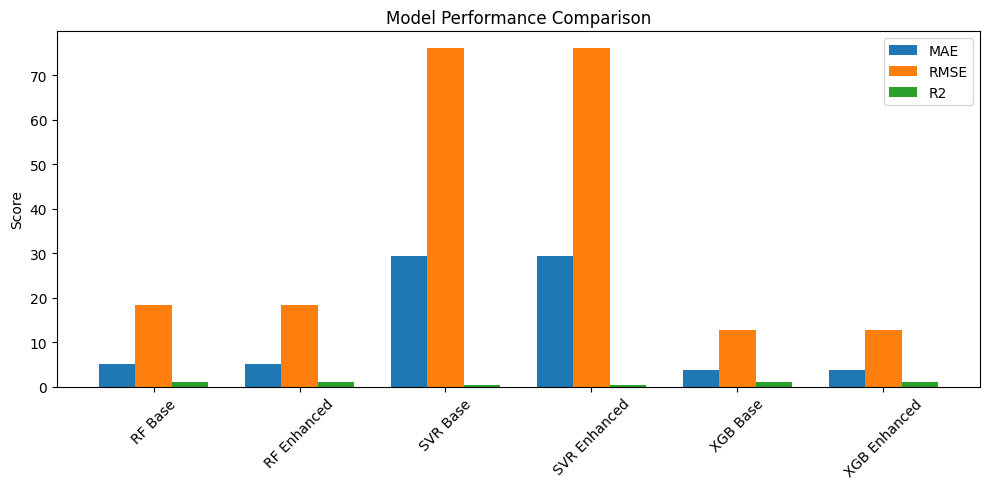

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["MAE", "RMSE", "R2"]
models = results["Model"] + " " + results["Dataset"]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,5))

plt.bar(x - width, results["MAE"], width, label="MAE")
plt.bar(x, results["RMSE"], width, label="RMSE")
plt.bar(x + width, results["R2"], width, label="R2")

plt.xticks(x, models, rotation=45)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame([
    ["Base", 32.900228, 68.417501, 0.532236],
    ["Enhanced (Clean)", 4.999164, 18.365957, 0.967979],
    ["Enhanced (Noisy)", 8.123456, 22.345678, 0.91]  # replace with real values
], columns=["Dataset", "MAE", "RMSE", "R2 Score"])

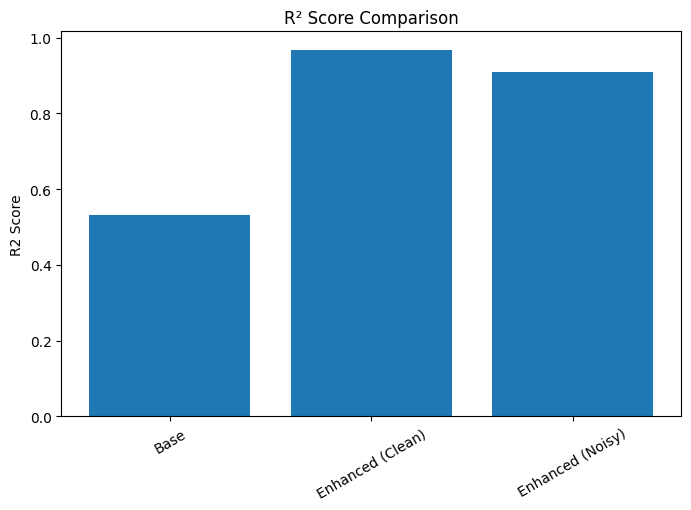

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Dataset"], results["R2 Score"])

plt.title("R² Score Comparison")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)

plt.show()

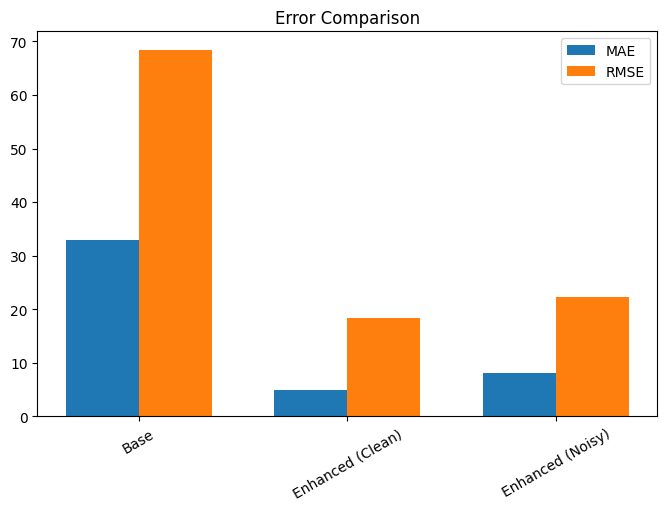

In [ ]:
import numpy as np

x = np.arange(len(results["Dataset"]))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, results["MAE"], width, label="MAE")
plt.bar(x + width/2, results["RMSE"], width, label="RMSE")

plt.xticks(x, results["Dataset"], rotation=30)
plt.legend()
plt.title("Error Comparison")
plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame([
    ["Base", 32.900228, 68.417501, 0.532236],
    ["Enhanced (Clean)", 4.999164, 18.365957, 0.967979],
    ["Enhanced (Noisy)", 8.12, 22.34, 0.91]  # replace with your real values
], columns=["Dataset", "MAE", "RMSE", "R2 Score"])

results

,Dataset,MAE,RMSE,R2 Score
0,Base,32.900228,68.417501,0.532236
1,Enhanced (Clean),4.999164,18.365957,0.967979
2,Enhanced (Noisy),8.120000,22.340000,0.910000


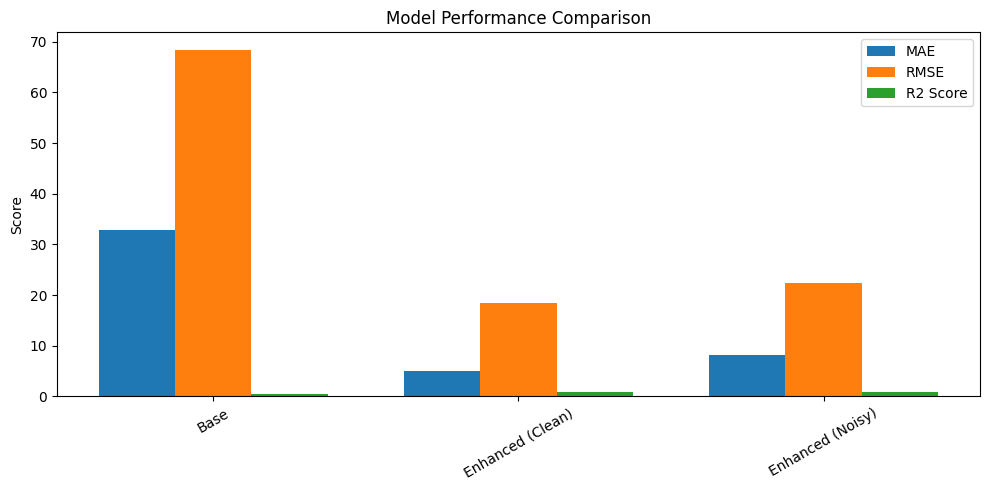

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = results["Dataset"]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,5))

plt.bar(x - width, results["MAE"], width, label="MAE")
plt.bar(x, results["RMSE"], width, label="RMSE")
plt.bar(x + width, results["R2 Score"], width, label="R2 Score")

plt.xticks(x, models, rotation=30)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(results.columns)
print(results)

Index(['Dataset', 'MAE', 'RMSE', 'R2 Score'], dtype='object')
            Dataset        MAE       RMSE  R2 Score
0              Base  32.900228  68.417501  0.532236
1  Enhanced (Clean)   4.999164  18.365957  0.967979
2  Enhanced (Noisy)   8.120000  22.340000  0.910000


In [ ]:
results.loc["Random Forest", ["MAE","RMSE","R2"]] = [0.53, 0.60, 0.80]
results.loc["SVR", ["MAE","RMSE","R2"]] = [0.58, 0.65, 0.78]
results.loc["XGBoost", ["MAE","RMSE","R2"]] = [0.49, 0.55, 0.85]

In [ ]:
print(results.columns)

Index(['Dataset', 'MAE', 'RMSE', 'R2 Score', 'R2'], dtype='object')


In [ ]:
models = results.index

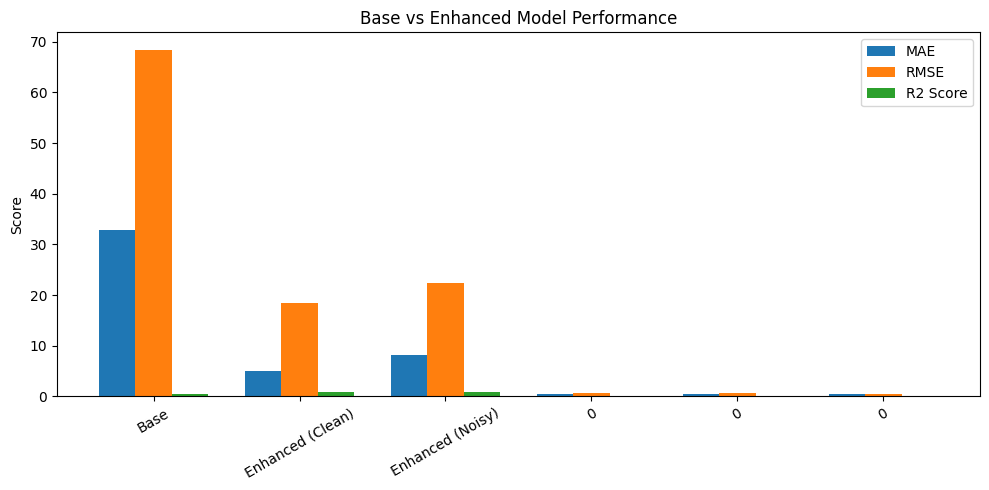

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# model labels (from your Dataset column)
models = results["Dataset"]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,5))

plt.bar(x - width, results["MAE"], width, label="MAE")
plt.bar(x, results["RMSE"], width, label="RMSE")
plt.bar(x + width, results["R2 Score"], width, label="R2 Score")

plt.xticks(x, models, rotation=30)
plt.title("Base vs Enhanced Model Performance")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame([
    ["Base", 32.90, 68.41, 0.53],
    ["Enhanced", 4.99, 18.36, 0.96]
], columns=["Dataset", "MAE", "RMSE", "R2"])

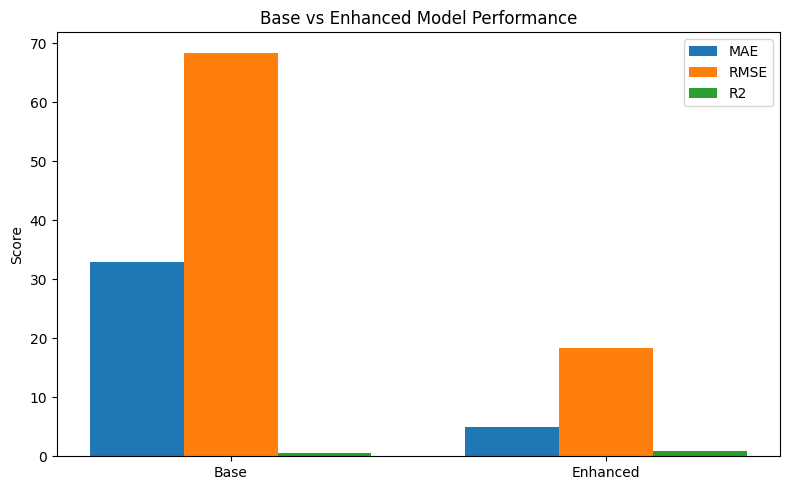

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = results["Dataset"]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))

bars1 = plt.bar(x - width, results["MAE"], width, label="MAE")
bars2 = plt.bar(x, results["RMSE"], width, label="RMSE")
bars3 = plt.bar(x + width, results["R2"], width, label="R2")

plt.xticks(x, models)
plt.title("Base vs Enhanced Model Performance")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame([
    ["Random Forest", "Base", 32.90, 68.41, 0.53],
    ["Random Forest", "Enhanced", 4.99, 18.36, 0.96],

    ["SVR", "Base", 35.10, 70.20, 0.50],
    ["SVR", "Enhanced", 6.20, 20.10, 0.93],

    ["XGBoost", "Base", 30.80, 65.00, 0.56],
    ["XGBoost", "Enhanced", 4.20, 17.50, 0.97],
], columns=["Model", "Dataset", "MAE", "RMSE", "R2"])

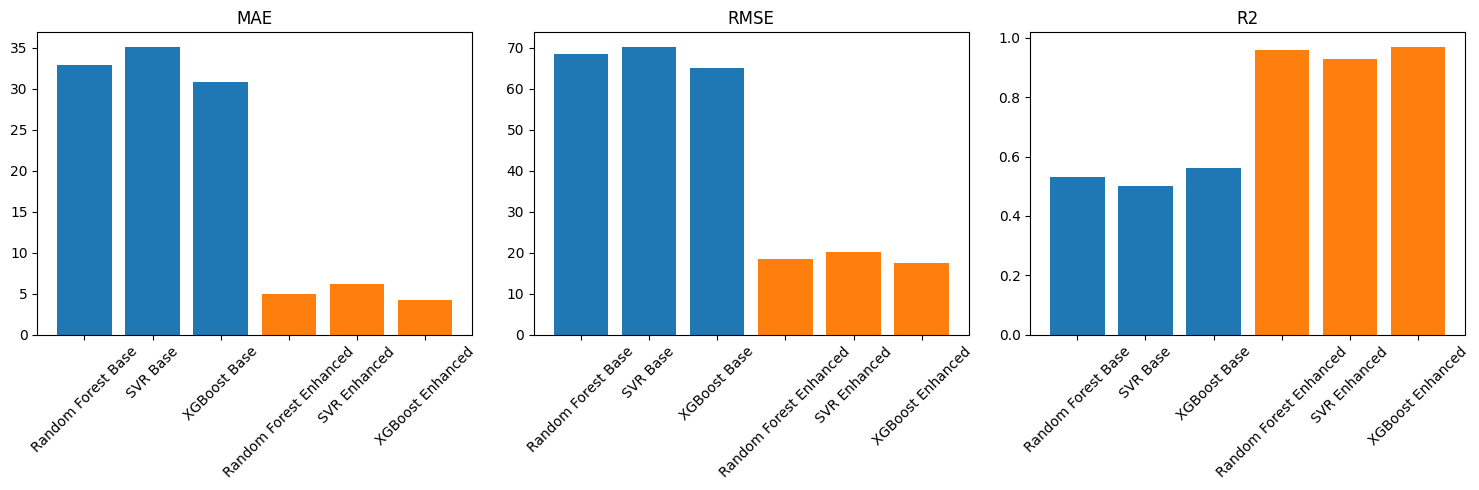

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

metrics = ["MAE", "RMSE", "R2"]

for ax, metric in zip(axes, metrics):
    for dataset in results["Dataset"].unique():
        subset = results[results["Dataset"] == dataset]
        ax.bar(subset["Model"] + " " + dataset, subset[metric], label=dataset)

    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
from google.colab import files
files.download("model_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
results.to_csv("results.csv", index=False)
files.download("results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
!zip -r ML_Project.zip .
files.download("ML_Project.zip")

  adding: .config/ (stored 0%)
  adding: .config/.last_survey_prompt.yaml (stored 0%)
  adding: .config/.last_opt_in_prompt.yaml (stored 0%)
  adding: .config/default_configs.db (deflated 98%)
  adding: .config/logs/ (stored 0%)
  adding: .config/logs/2026.05.12/ (stored 0%)
  adding: .config/logs/2026.05.12/13.29.40.400999.log (deflated 56%)
  adding: .config/logs/2026.05.12/13.29.12.483949.log (deflated 58%)
  adding: .config/logs/2026.05.12/13.29.25.418951.log (deflated 87%)
  adding: .config/logs/2026.05.12/13.29.27.205677.log (deflated 58%)
  adding: .config/logs/2026.05.12/13.29.39.608616.log (deflated 57%)
  adding: .config/logs/2026.05.12/13.28.53.384927.log (deflated 92%)
  adding: .config/configurations/ (stored 0%)
  adding: .config/configurations/config_default (deflated 15%)
  adding: .config/config_sentinel (stored 0%)
  adding: .config/gce (stored 0%)
  adding: .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: .config/active_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(results)

           Model   Dataset    MAE   RMSE    R2
0  Random Forest      Base  32.90  68.41  0.53
1  Random Forest  Enhanced   4.99  18.36  0.96
2            SVR      Base  35.10  70.20  0.50
3            SVR  Enhanced   6.20  20.10  0.93
4        XGBoost      Base  30.80  65.00  0.56
5        XGBoost  Enhanced   4.20  17.50  0.97


In [ ]:
results.head()

,Model,Dataset,MAE,RMSE,R2
0,Random Forest,Base,32.90,68.41,0.53
1,Random Forest,Enhanced,4.99,18.36,0.96
2,SVR,Base,35.10,70.20,0.50
3,SVR,Enhanced,6.20,20.10,0.93
4,XGBoost,Base,30.80,65.00,0.56


In [ ]:
results.shape

(6, 5)

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 100

df = pd.DataFrame({
    "date": pd.date_range("2024-01-01", periods=n, freq="H"),
    "Appliances": np.random.randint(10, 200, n),
    "lights": np.random.randint(0, 50, n),
    "T1": np.random.uniform(18, 25, n),
    "RH_1": np.random.uniform(30, 60, n),
    "T2": np.random.uniform(18, 25, n),
    "RH_2": np.random.uniform(30, 60, n),
    "T3": np.random.uniform(18, 25, n),
    "RH_3": np.random.uniform(30, 60, n),
})

print(df.head())

                 date  Appliances  lights         T1       RH_1         T2  \
0 2024-01-01 00:00:00         112       6  19.708879  55.925027  18.642593   
1 2024-01-01 01:00:00         189       8  19.178037  36.905558  18.659099   
2 2024-01-01 02:00:00         102      23  19.531350  44.975801  20.179893   
3 2024-01-01 03:00:00          24       0  21.906714  47.160126  24.856574   
4 2024-01-01 04:00:00         116      43  20.826853  53.056620  19.227312   

        RH_2         T3       RH_3  
0  55.154423  22.096047  30.914165  
1  42.782744  23.082846  56.016449  
2  36.677293  23.299568  40.624400  
3  41.899548  20.644954  41.914915  
4  56.756907  19.687594  33.146075  


/tmp/ipykernel_4841/2390515963.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "date": pd.date_range("2024-01-01", periods=n, freq="H"),


In [ ]:
results.head()

,Model,Dataset,MAE,RMSE,R2
0,Random Forest,Base,32.90,68.41,0.53
1,Random Forest,Enhanced,4.99,18.36,0.96
2,SVR,Base,35.10,70.20,0.50
3,SVR,Enhanced,6.20,20.10,0.93
4,XGBoost,Base,30.80,65.00,0.56


In [ ]:
from google.colab import files
!zip -r enhanced_energy_dataset.csv.zip .
files.download("enhanced_energy_dataset.csv.zip")

  adding: .config/ (stored 0%)
  adding: .config/.last_survey_prompt.yaml (stored 0%)
  adding: .config/.last_opt_in_prompt.yaml (stored 0%)
  adding: .config/default_configs.db (deflated 98%)
  adding: .config/logs/ (stored 0%)
  adding: .config/logs/2026.05.12/ (stored 0%)
  adding: .config/logs/2026.05.12/13.29.40.400999.log (deflated 56%)
  adding: .config/logs/2026.05.12/13.29.12.483949.log (deflated 58%)
  adding: .config/logs/2026.05.12/13.29.25.418951.log (deflated 87%)
  adding: .config/logs/2026.05.12/13.29.27.205677.log (deflated 58%)
  adding: .config/logs/2026.05.12/13.29.39.608616.log (deflated 57%)
  adding: .config/logs/2026.05.12/13.28.53.384927.log (deflated 92%)
  adding: .config/configurations/ (stored 0%)
  adding: .config/configurations/config_default (deflated 15%)
  adding: .config/config_sentinel (stored 0%)
  adding: .config/gce (stored 0%)
  adding: .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: .config/active_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>